# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [47]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


### Cargar Dataset

In [48]:
# Cargar el dataset y explorar datos
df = df = pd.read_csv("data/raw/novaretail_comportamiento_clientes_2024.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [49]:
# mostrar las primeras 5 filas
df.head()

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza


El DataFrame contiene 12 columnas: 4 de tipo int64, 5 de tipo float64 y 3 de tipo object. No se identifican valores nulos.

La variable miembro_premium utiliza valores 0 y 1, por lo que se recomienda convertirla a tipo bool para representar correctamente su naturaleza binaria y facilitar su análisis.




#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- `nivel_ingreso`
- `visitas_mes`
- `compras_mes`
- `gastos_publicidad_dirigida`
- `satisfaccion`
- `miembro_premium`
- `abondono`

La mayoría de estas variables presentan tipos de datos adecuados.  
Las columna edad,nivel_ingreso,gasto_publicidad_dirigida,satisfaccion,ingreso_mensual son de tipo float64
las columnas visitas_mes,compras_mes,miembro_premium,abondono son de tipo int64
las columnas id_cliente,tipo_dispositivo,region son de tipo object

**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [50]:
# Corregir el tipo de dato
df["miembro_premium"] = df["miembro_premium"].astype(bool)
df["abandono"] = df["abandono"].astype(bool)

In [51]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  bool   
 8   abandono                   15000 non-null  bool   
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: bool(2), float64(5), int64(2), object(3)
memory usage: 1.2+ MB


#### Explorar variables numéricas

In [52]:
# Estadísticas descriptivas de variables numéricas
df_numericas = ["edad","nivel_ingreso","visitas_mes","compras_mes","gasto_publicidad_dirigida","satisfaccion","ingreso_anual"]
df[df_numericas].describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,244.690000



✍️ **Comentario**:
Se analizaron 15.000 registros y no se observan valores faltantes. En general, las variables presentan rangos coherentes, aunque se identifican diferencias importantes en su dispersión.

- Edad: media de 38,3 años, con valores entre 18 y 75.
- Nivel de ingreso: media de 30.019,7, con un rango de 8.000 a 74.790,8, mostrando una dispersión considerable.
- Visitas al mes: promedio de 10 visitas, con un rango de 1 a 25.
- Compras al mes: promedio de 1,2 compras, aunque algunos clientes alcanzan hasta 8.
- Gasto en publicidad dirigida: promedio de 20,15, con valores entre 0 y 75,51.
- Satisfacción: media de 3,60 sobre 5, con valores entre 1 y 5.
- Ingreso anual: media de 36,59, con valores entre 0 y 244,69, mostrando una alta dispersión respecto a su media y posibles valores extremos que deberán revisarse posteriormente.

#### Explorar variables binarias

In [53]:

# Verificar que cada columna tenga únicamente dos valores posibles

for col in ["miembro_premium", "abandono"]:
    print(f"Valores únicos en {col}:", df[col].unique())


print()
print("Valores nulos")
df[["miembro_premium", "abandono"]].isna().count()


Valores únicos en miembro_premium: [False  True]
Valores únicos en abandono: [False  True]

Valores nulos


,0
miembro_premium,15000
abandono,15000


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables binarias

- `miembro_premium`: solo contiene valores True y False, sin valores anómalos.
- `abandono`: solo contiene valores True y False, sin valores anómalos.
Después de convertir miembro_premium de int64 a bool, se verificó que no se perdieran registros ni aparecieran valores nulos. Ambas variables contienen 15.000 registros válidos y 0 valores nulos.


#### Explorar variables categóricas

In [54]:
# Verificar el número de valores únicos por variable categórica
column_categ = ["region","tipo_dispositivo"]

for col in column_categ:
    print(f"Valores únicos en {col}:", df[col].unique())



Valores únicos en region: ['norte' 'sur' 'este' 'oeste']
Valores únicos en tipo_dispositivo: ['móvil' 'tablet' 'escritorio']


In [55]:

# Explorar variables categóricas y cómo se distribuyen
for col in column_categ:
    print(col)
    print(df[col].value_counts(), )
    print(df[col].value_counts(normalize=True))
    print("suma de procentajes",df[col].value_counts(normalize=True).sum())
    print()




region
region
norte    4395
oeste    3810
sur      3726
este     3069
Name: count, dtype: int64
region
norte    0.2930
oeste    0.2540
sur      0.2484
este     0.2046
Name: proportion, dtype: float64
suma de procentajes 0.9999999999999999

tipo_dispositivo
tipo_dispositivo
móvil         9818
escritorio    3720
tablet        1462
Name: count, dtype: int64
tipo_dispositivo
móvil         0.654533
escritorio    0.248000
tablet        0.097467
Name: proportion, dtype: float64
suma de procentajes 1.0



 **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables categóricas

- tipo_dispositivo: presenta 3 categorías, sin valores nulos. La distribución está concentrada en móvil (65,45%), seguido de escritorio (24,80%) y tablet (9,75%). Los porcentajes suman el 100% de los registros.
- region: presenta 4 categorías, sin valores nulos. La distribución es relativamente equilibrada, aunque norte concentra la mayor proporción (29,30%) y este la menor (20,46%). La suma de porcentajes es 0,9999999999999999, equivalente al 100%; esta pequeña diferencia se debe al redondeo de los valores decimales y no representa un registro faltante o un error de conteo.

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

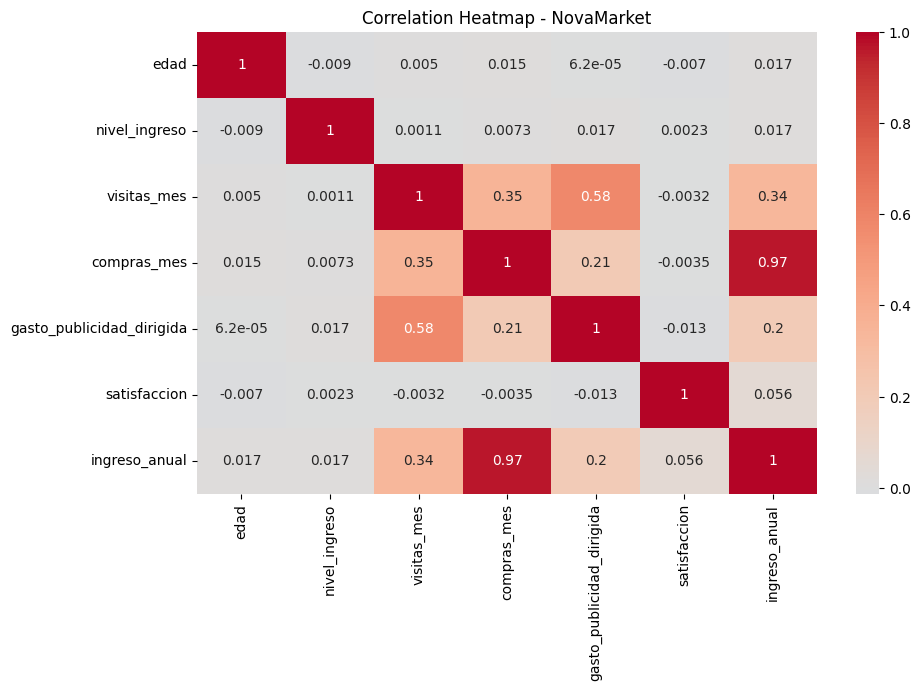

In [56]:
# Visualizar la matriz de correlación para identificar relaciones
corr = df[df_numericas].corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap - NovaMarket")
plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   

Observaciones generales — Heatmap
- La mayoría de las variables presentan correlaciones bajas o moderadas, por lo que no se observa una relación lineal fuerte generalizada entre los comportamientos analizados.
- Se destaca la relación entre `visitas_mes` y `compras_mes`, lo que indica que ambas variables presentan un comportamiento lineal positivo.
`gasto_publicidad_dirigida` presenta una relación positiva con `visitas_mes` y, en medida media, con `compras_mes`. Estas asociaciones describen el comportamiento observado, pero no permiten determinar si la publicidad genera un aumento en visitas o compras.
  
Observaciones respecto a `ingreso_anual`
- `ingreso_anual` presenta una relación positiva con `visitas_mes`, aunque de menor magnitud que otras asociaciones observadas.
- La relación con 'compras_mes' es muy alta (0,97). Este es el principal hallazgo del heatmap y requiere una revisión específica para comprender qué características de los clientes explican esta asociación.
`gasto_publicidad_dirigida` presenta una relación positiva baja (0,20) con ingreso_anual, por lo que la asociación observada es limitada.
- La relación entre `ingreso_anual` y `satisfaccion` es positiva, pero baja, por lo que no constituye una asociación lineal destacable dentro de este análisis.

### Scatterplot general


No considero necesario incluirlo en el analisis ya que seria mejor enfocarse en los segmentos particulares de relevancia anteriormente mencionados

### Scatterplot para pares clave

In [57]:
# Visualizar pares de variables con relaciones moderadas o fuertes
# Crear scatterplot y línea de tendencia

def graficar_relacion(df, x, y, hue=None, markers=None):
    plt.figure(figsize=(8, 5))

    sns.scatterplot(
        data=df,
        x=x,
        y=y,
    )
    sns.regplot(
        data=df,
        x=x,
        y=y,
        scatter=False,

        color='red',
        line_kws={'linestyle': '--'}

    )
    plt.title(f"Relación entre {x.replace('_', ' ').title()} y {y.replace('_', ' ').title()}")
    plt.xlabel(x.replace("_", " ").title())
    plt.ylabel(y.replace("_", " ").title())

    plt.tight_layout()
    plt.show()




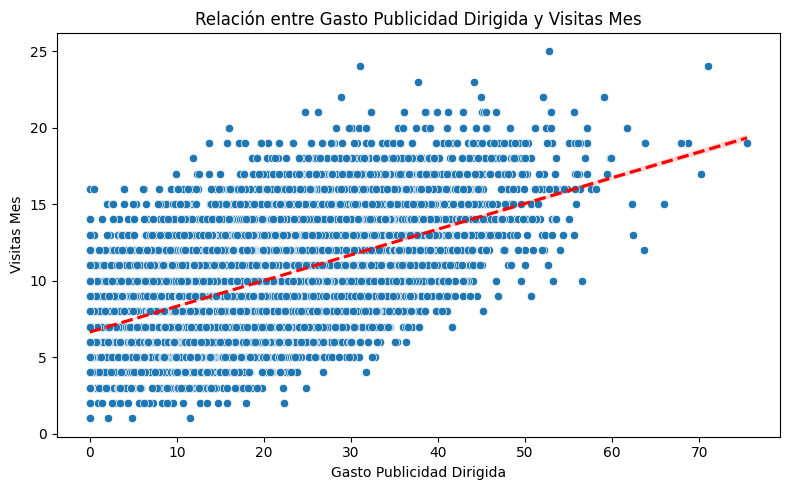

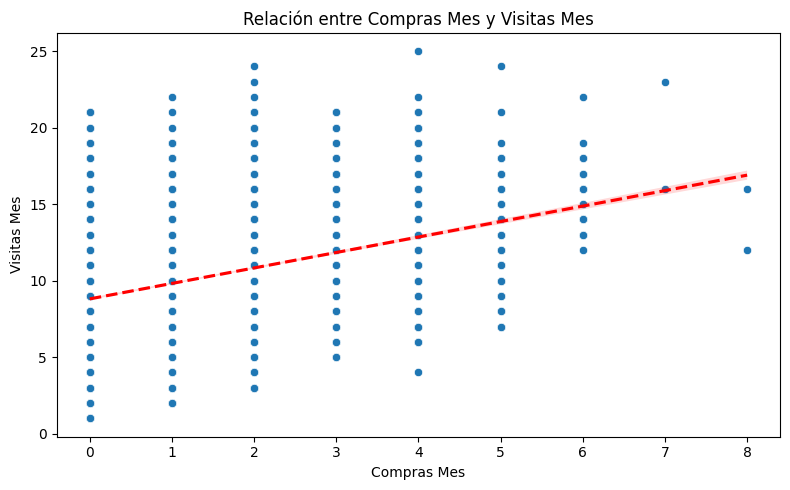

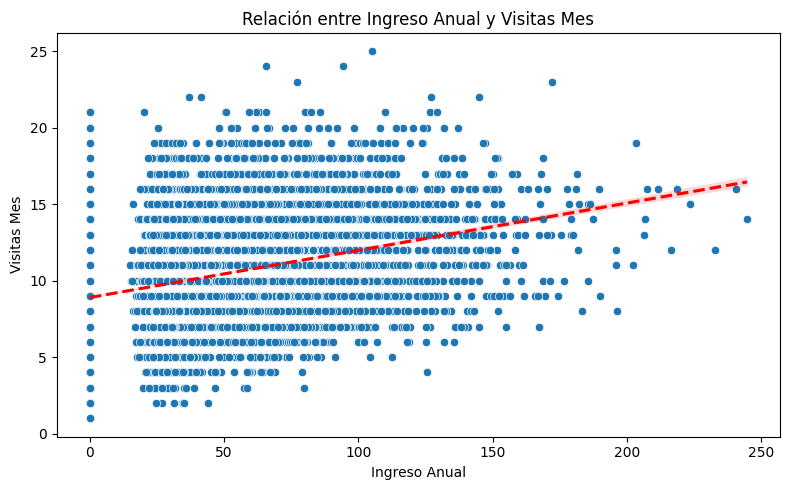

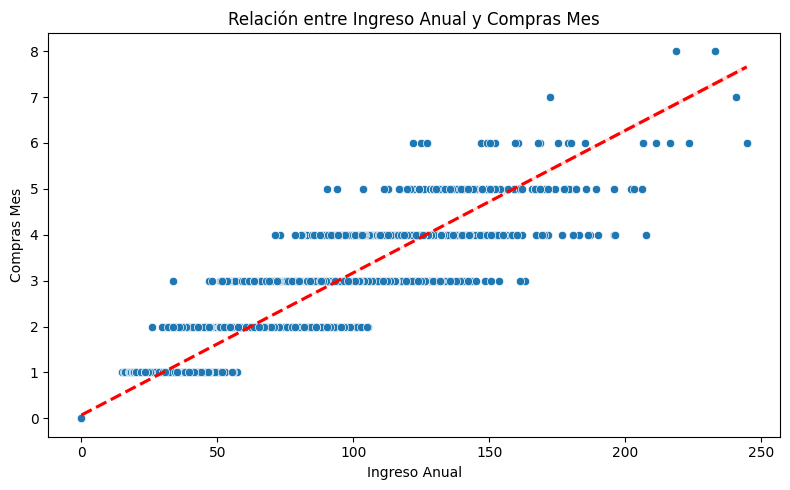

In [58]:



comparaciones = [
    ("gasto_publicidad_dirigida", "visitas_mes"),
    ("compras_mes", "visitas_mes"),
    ("ingreso_anual", "visitas_mes"),
    ("ingreso_anual", "compras_mes"),
]


# Ejecutar la función para cada par
for var_x, var_y in comparaciones:
    # Para pares numéricos podemos incluir tipo_dispositivo si aplica
    hue_var = "tipo_dispositivo" if df[var_x].nunique() > 5 and df[var_y].nunique() > 5 else None

    graficar_relacion(
        df=df,
        x=var_x,
        y=var_y,
    )



✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), dispersión (alta, media, baja), presencia de outliers y posible colinealidad.


Observaciones iniciales (Scatterplot)

**Análisis de Resultados de las Gráficas**

* **Compras Mes vs. Visitas Mes:** Tendencia **positiva (ascendente)**. A mayor número de compras al mes, se observan en general mayores niveles de visitas al mes.
* **Gasto Publicidad Dirigida vs. Visitas Mes:** Tendencia **positiva (ascendente)**. A mayores montos registrados en gasto de publicidad dirigida, se observa una mayor cantidad de visitas mensuales.
* **Ingreso Anual vs. Visitas Mes:** Tendencia **positiva moderada (ascendente)**. Los niveles más altos de ingreso anual tienden a coincidir con un mayor promedio de visitas al mes, aunque con una dispersión amplia.
* **Ingreso Anual vs. Compras Mes:** Tendencia **positiva fuerte (ascendente)**. Muestra una clara alineación donde a mayores ingresos anuales corresponden mayores volúmenes de compras mensuales.

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [59]:

def graficar_corr_numerica(df, a,b, metodo="pearson"):
    matriz = df[[a,b]].corr(method=metodo)
    print("correlacion", a, " con ", b, "- tipo:",m)
    print(matriz)
    print();

In [60]:
# Bucle para graficar par por par
comparacionespp = [
    ("compras_mes", "visitas_mes","spearman"),
    ("gasto_publicidad_dirigida", "visitas_mes","pearson"),
    ("ingreso_anual", "visitas_mes","spearman"),
    ("ingreso_anual", "compras_mes","spearman"),
]


for a,b,m in comparacionespp:
    graficar_corr_numerica(df, a,b,m)

correlacion compras_mes  con  visitas_mes - tipo: spearman
             compras_mes  visitas_mes
compras_mes     1.000000     0.332943
visitas_mes     0.332943     1.000000

correlacion gasto_publicidad_dirigida  con  visitas_mes - tipo: pearson
                           gasto_publicidad_dirigida  visitas_mes
gasto_publicidad_dirigida                   1.000000     0.578947
visitas_mes                                 0.578947     1.000000

correlacion ingreso_anual  con  visitas_mes - tipo: spearman
               ingreso_anual  visitas_mes
ingreso_anual       1.000000     0.320954
visitas_mes         0.320954     1.000000

correlacion ingreso_anual  con  compras_mes - tipo: spearman
               ingreso_anual  compras_mes
ingreso_anual       1.000000     0.967482
compras_mes         0.967482     1.000000



✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves: dirección, magnitud y posible colinealidad.


Observaciones de correlación
- compras_mes vs. visitas_mes — spearman = 0,333: existe una asociación monotónica positiva moderada-baja. En general, mayores niveles de visitas tienden a estar asociados con mayores compras, aunque la relación no es especialmente fuerte.
- gasto_publicidad_dirigida vs. visitas_mes — spearman = 0,579: existe una asociación lineal positiva moderada. A mayores niveles de gasto en publicidad dirigida, se observan, en promedio, mayores niveles de visitas.
- ingreso_anual vs. visitas_mes — spearman = 0,321: se observa una asociación monotónica positiva moderada-baja. Los clientes con mayores ingresos anuales tienden a presentar más visitas, pero la asociación es limitada.
- ingreso_anual vs. compras_mes — spearman = 0,967: se observa una asociación monotónica positiva muy fuerte. Es el hallazgo más destacado de las correlaciones analizadas y merece una investigación específica para entender qué patrón de los datos explica esta relación.


### biserial

In [61]:

def corr_point_biserial(df, col_binaria, columnas_numericas):
    resultados = []

    for col in columnas_numericas:
        # Eliminar filas con valores nulos en ambas columnas
        sub_df = df[[col_binaria, col]].dropna()

        # Calcular correlación punto biserial
        coef, p_value = stats.pointbiserialr(sub_df[col_binaria], sub_df[col])

        # Imprimir identificando la columna actual
        print(f"Columna: {col} | Coeficiente: {coef:.4f} | p-valor: {p_value:.6f}")

        resultados.append({
            "columna": col,
            "coeficiente": round(coef, 4),
            "p_valor": round(p_value, 6)
        })

    # Retornar como DataFrame estructurado
    return pd.DataFrame(resultados)


In [65]:
print("--- miembro_premium con ingreso anual---")
corr_point_biserial(df, "miembro_premium", ["ingreso_anual"])



--- miembro_premium con ingreso anual---
Columna: ingreso_anual | Coeficiente: 0.0931 | p-valor: 0.000000


,columna,coeficiente,p_valor
0,ingreso_anual,0.0931,0.0



✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), magnitud (alta, media, baja).

- miembro_premium vs ingreso anual es una variable de correlacion que podria ser de interes para el analisis pero su valor de correlacion representa un valor muy bajo de 0.0931 por lo cual sedeberia investigar mas a profundidad.


### V de Cramer

In [63]:
from scipy.stats import chi2_contingency

def cramer_v(df, col1, col2):
    # Tabla de contingencia
    tabla = pd.crosstab(df[col1], df[col2])

    # Validar que haya al menos 2 categorías por columna
    r, k = tabla.shape
    if min(r, k) < 2:
        return 0.0, 1.0  # V de Cramér = 0, p-valor = 1 (sin asociación)

    # Calcular Chi-cuadrado
    chi2, p_value, dof, expected = chi2_contingency(tabla)

    # Calcular coeficiente V de Cramér
    n = tabla.values.sum()
    v = np.sqrt(chi2 / (n * (min(r, k) - 1)))

    # Retorna tanto el coeficiente como el p-valor
    return round(v, 4), round(p_value, 6)

In [64]:
# Aplicar V de Cramér en variables relevantes
print("Tipo_dispositivo con region: ",cramer_v(df, "tipo_dispositivo", "region"))
print("abandono con tipo_dispositivo: ",cramer_v(df, "abandono", "tipo_dispositivo"))
print("abandono con region: ",cramer_v(df, "abandono", "region"))
print("abandono con miembro_premium: ",cramer_v(df, "abandono", "miembro_premium"))

Tipo_dispositivo con region:  (np.float64(0.0124), np.float64(0.596477))
abandono con tipo_dispositivo:  (np.float64(0.0072), np.float64(0.674559))
abandono con region:  (np.float64(0.0154), np.float64(0.311652))
abandono con miembro_premium:  (np.float64(0.1202), np.float64(0.0))


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.
Incluye qué ves

Observaciones V de Cramér

- tipo_dispositivo vs. region — V = 0,0124: presenta una asociación muy baja, prácticamente inexistente.
- abandono vs. tipo_dispositivo — V = 0,0072: presenta una asociación muy baja, sin una relación relevante entre ambas variables.
- abandono vs. region — V = 0,0154: presenta una asociación muy baja, sin evidencia de una relación relevante entre las variables categóricas.
- abondono vs. miembro_premium - V = 0.1202:presenta una correlacion baja, pero mereces su propio analisis ya que evidencia un punto relevante para investigar alguna variable que interviene en la retencion

## Sección 5 - Interpretación de resultados para el negocio

Cada hallazgo  debe incluir:
1) Evidencia visual (si aplica)
2) Evidencia numérica  
3) Interpretación (no causal)  
4) No podemos afirmar
5) Implicación de negocio

---


### Hallazgo 1 — Correlacion compras_mes con ingreso anual

**Evidencia visual:**  ![image.png](attachment:0b23d0c4-daaf-4d1f-beaf-04464466f4e4.png)

**Evidencia numérica:** 0.97

**Interpretación**  existe una asociación monotónica positiva muy fuerte entre la cantidad de compras mensuales y el ingreso anual. Los clientes con mayor número de compras al mes tienden a presentar mayores niveles de ingreso anual.


**No podemos afirmar** la correlación no permite determinar causalidad ni establecer que un aumento en las compras produzca directamente un aumento del ingreso anual. La magnitud de la asociación también hace necesario investigar si existe alguna relación estructural entre ambas variables.


**Implicación de negocio**  compras_mes aparece como una variable especialmente relevante para segmentar y analizar los clientes según su generación de ingresos. Se recomienda profundizar en esta relación mediante segmentaciones y análisis adicionales para identificar qué perfiles de clientes concentran los mayores niveles de ingreso anual.




### Hallazgo 2 — Baja correlacion con ingresos anuales

**Evidencia visual:**  ![image.png](attachment:2c74b72c-bae2-4ac6-b595-4cb8bd66c516.png)

**Evidencia numérica:** las asociaciones más destacables con ingreso_anual, fuera de compras_mes, son visitas_mes (ρ = 0,32) y gasto_publicidad_dirigida (r = 0,20).

**Interpretación**  compras_mes se diferencia claramente del resto de variables por su asociación con ingreso_anual. Las demás variables presentan relaciones considerablemente menores, por lo que el comportamiento del ingreso anual no queda suficientemente descrito mediante estas correlaciones.


**No podemos afirmar**  una baja correlación no significa que una variable no tenga ningún efecto sobre el ingreso anual. Puede existir una relación no lineal, interacción con otras variables o influencia de factores que no están incluidos en el conjunto de datos.


**Implicación de negocio** sería conveniente ampliar el análisis incorporando segmentaciones y combinaciones de variables para identificar otros patrones asociados con ingreso_anual, especialmente aquellos que no pueden detectarse mediante una correlación simple.




### Hallazgo 3 — ingreso anual con visitas al mes

**Evidencia visual:**  ![image.png](attachment:041d5d29-8cd1-48c8-9363-c223139ea6ce.png)

**Evidencia numérica:** ρ = 0,32

**Interpretación** existe una asociación monotónica positiva baja-moderada entre visitas_mes e ingreso_anual. Los clientes con más visitas tienden a presentar mayores ingresos anuales, aunque la magnitud de la relación es limitada.


**No podemos afirmar**  que un mayor número de visitas produzca un aumento del ingreso anual. También es necesario determinar si esta asociación se concentra en determinados segmentos de clientes.


**Implicación de negocio** se recomienda segmentar a los clientes según su comportamiento de visitas y analizar qué perfiles presentan simultáneamente mayores niveles de visitas e ingresos, para identificar patrones que puedan ser relevantes para las estrategias de retención y crecimiento.



## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**
- El análisis es correlacional y exploratorio, por lo que las asociaciones identificadas no permiten establecer relaciones causales.
- La fuerte asociación entre compras_mes e ingreso_anual requiere un análisis más profundo para comprender qué características de los clientes explican este patrón.
- Las correlaciones simples pueden ocultar diferencias entre segmentos. Variables como region, tipo_dispositivo, edad y miembro_premium podrían presentar comportamientos diferentes cuando se analizan conjuntamente.
- El conjunto de variables disponible puede no incluir todos los factores relacionados con la generación de ingresos, por lo que una correlación baja no implica necesariamente que una variable carezca de relevancia.

### **Próximos pasos**

## Paso 1 — Segmentación por comportamiento y contexto

- Analizar ingreso_anual y compras_mes por región para identificar diferencias en el comportamiento de compra y generación de ingresos entre zonas.
-  Comparar tipo_dispositivo, visitas_mes y compras_mes para identificar diferencias en la conversión de visitas en compras según el dispositivo.
- Segmentar por rangos de edad para determinar si los patrones de visitas y compras varían entre grupos etarios.

## Paso 2 — Análisis de membresía

- Comparar clientes miembro_premium y no premium respecto a compras_mes, ingreso_anual, visitas_mes y abandono.
- Evaluar si existen diferencias relevantes en los hábitos de compra y abandono entre ambos grupos.

## Paso 3 — Análisis combinado

- Cruzar variables como región + dispositivo + edad + membresía para identificar segmentos con comportamientos diferenciados.
- Analizar qué combinaciones de características concentran mayores niveles de compras_mes e ingreso_anual.
- Profundizar en los segmentos con mayor abandono para identificar patrones de comportamiento asociados.